In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
WIKIART_DIR = '/content/drive/MyDrive/wikiart'

In [ ]:
!pip install open-clip-torch transformers gradio tqdm -q

print('✅ Έτοιμο!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
✅ Έτοιμο!


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
import open_clip
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Device
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'✅ GPU: {torch.cuda.get_device_name(0)}')
else:
    DEVICE = torch.device('cpu')
    print('⚠️ CPU mode')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

⚠️ CPU mode


In [ ]:
# ══════════════════════════════════════════════════
# ΑΛΛΑΞΕ ΜΟΝΟ ΑΥΤΟ — βάλε το σωστό path από το Drive σου
# Πήγαινε στο Drive, δεξί κλικ στον φάκελο → Copy path
WIKIART_DIR = Path('/content/drive/MyDrive/wikiart_100')
# ══════════════════════════════════════════════════

MODELS_DIR = Path('/content/saved_models')
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE             = 224
BATCH_SIZE           = 32
NUM_EPOCHS           = 10
LR                   = 1e-4
MAX_SAMPLES_PER_CLASS = 100  # έχεις ήδη 100 ανά style
MAX_CLASSES          = None  # όλα τα 27 styles

print('✅ Paths OK')
print(f'   WikiArt: {WIKIART_DIR}')
print(f'   Exists: {WIKIART_DIR.exists()}')

✅ Paths OK
   WikiArt: /content/drive/MyDrive/wikiart_100
   Exists: True


Loading styles: 100%|██████████| 27/27 [00:02<00:00, 10.17it/s]


✅ Σύνολο εικόνων : 2,698
   Styles          : 27
   Genres          : 1
   Artists         : 676


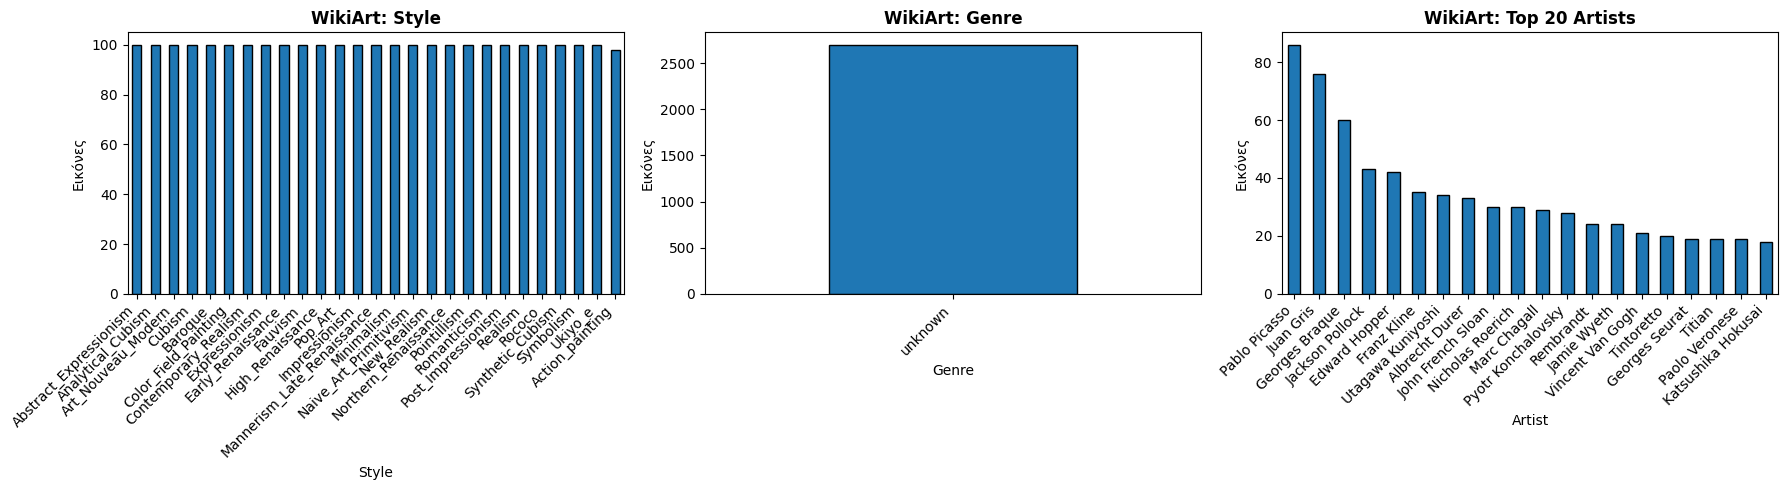

In [ ]:
def load_wikiart_from_folders(root_dir, max_classes=None, max_samples_per_class=None):
    """
    Υποστηρίζει δομή:
    wikiart_100/
        genre_name/
            style_name/
                artist_name_title.jpg
    ή απλή δομή:
    wikiart_100/
        style_name/
            img.jpg
    """
    root = Path(root_dir)
    records = []

    # Ανίχνευση δομής — αν οι υποφάκελοι περιέχουν κι αυτοί φακέλους
    first_sub = next(d for d in root.iterdir() if d.is_dir())
    has_nested = any(d.is_dir() for d in first_sub.iterdir())

    if has_nested:
        # Δομή: genre/style/images
        genre_dirs = [d for d in sorted(root.iterdir()) if d.is_dir()]
        for genre_dir in genre_dirs:
            genre = genre_dir.name
            style_dirs = [d for d in sorted(genre_dir.iterdir()) if d.is_dir()]
            if max_classes:
                style_dirs = style_dirs[:max_classes]
            for style_dir in tqdm(style_dirs, desc=f'Genre: {genre}'):
                style = style_dir.name
                imgs = [p for p in style_dir.glob('*')
                        if p.suffix.lower() in ['.jpg','.jpeg','.png','.bmp']]
                if max_samples_per_class:
                    random.shuffle(imgs)
                    imgs = imgs[:max_samples_per_class]
                for img_path in imgs:
                    # Artist: πρώτο μέρος filename πριν το '_'
                    artist = img_path.stem.split('_')[0].replace('-',' ').title()
                    records.append({
                        'path':   str(img_path),
                        'style':  style,
                        'genre':  genre,
                        'artist': artist
                    })
    else:
        # Απλή δομή: style/images
        style_dirs = [d for d in sorted(root.iterdir()) if d.is_dir()]
        if max_classes:
            style_dirs = style_dirs[:max_classes]
        for style_dir in tqdm(style_dirs, desc='Loading styles'):
            style = style_dir.name
            imgs = [p for p in style_dir.glob('*')
                    if p.suffix.lower() in ['.jpg','.jpeg','.png','.bmp']]
            if max_samples_per_class:
                random.shuffle(imgs)
                imgs = imgs[:max_samples_per_class]
            for img_path in imgs:
                artist = img_path.stem.split('_')[0].replace('-',' ').title()
                records.append({
                    'path':   str(img_path),
                    'style':  style,
                    'genre':  'unknown',
                    'artist': artist
                })

    df = pd.DataFrame(records)
    return df

wikiart_df = load_wikiart_from_folders(WIKIART_DIR, MAX_CLASSES, MAX_SAMPLES_PER_CLASS)

print(f'✅ Σύνολο εικόνων : {len(wikiart_df):,}')
print(f'   Styles          : {wikiart_df["style"].nunique()}')
print(f'   Genres          : {wikiart_df["genre"].nunique()}')
print(f'   Artists         : {wikiart_df["artist"].nunique()}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in zip(axes,
                           ["style", "genre", "artist"],
                           ["Style", "Genre", "Top 20 Artists"]):
    counts = wikiart_df[col].value_counts()
    if col == 'artist':
        counts = counts.head(20)
    counts.plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title(f'WikiArt: {title}', fontweight='bold')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Εικόνες')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import os

# Βρες αυτόματα το CSV
csv_files = [f for f in os.listdir('/content') if f.endswith('.csv')]
ARTEMIS_CSV = '/content/artemis_dataset_release_v0.csv'

# Φόρτωση με error handling
artemis_df = pd.read_csv(
    ARTEMIS_CSV,
    on_bad_lines='skip',    # παράλειψε προβληματικές γραμμές
    engine='python',         # πιο ανεκτικός parser
    encoding='utf-8'
)

print(f'📊 ArtEmis: {len(artemis_df):,} annotations')
print(f'   Columns: {artemis_df.columns.tolist()}')
artemis_df.head(3)

📊 ArtEmis: 454,684 annotations
   Columns: ['art_style', 'painting', 'emotion', 'utterance', 'repetition']


,art_style,painting,emotion,utterance,repetition
0,Post_Impressionism,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,something else,"She seems very happy in the picture, and you w...",10
1,Post_Impressionism,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,sadness,This woman has really knotty hands which makes...,10
2,Post_Impressionism,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,something else,"When looking at this woman, I am filled with c...",10


In [ ]:
BASE = '/content/drive/MyDrive/WikiArt Dataset'

# ── Φόρτωση class files ───────────────────────────────────────────
def load_classes(filepath):
    with open(filepath, 'r') as f:
        lines = [l.strip() for l in f.readlines()]
    classes = {}
    for line in lines:
        if line:
            parts = line.split(' ', 1)
            classes[int(parts[0])] = parts[1]
    return classes

style_map = load_classes(f'{BASE}/Style/style_class.txt')
genre_map = load_classes(f'{BASE}/Genre/genre_class')

print(f'✅ Style map : {len(style_map)} classes')
print(f'   Genre map : {len(genre_map)} classes')

# ── Φόρτωση CSV splits ────────────────────────────────────────────
def load_split_csv(filepath, label_map, name='label'):
    df = pd.read_csv(filepath, header=None, skiprows=1)
    df.columns = ['filename', name]
    df[name] = df[name].map(label_map)
    return df.dropna()

style_train_df = load_split_csv(f'{BASE}/Style/style_train.csv', style_map, 'style')
style_val_df   = load_split_csv(f'{BASE}/Style/style_val.csv',   style_map, 'style')
genre_train_df = load_split_csv(f'{BASE}/Genre/genre_train.csv', genre_map, 'genre')
genre_val_df   = load_split_csv(f'{BASE}/Genre/genre_val.csv',   genre_map, 'genre')

print(f'\n✅ Splits:')
print(f'   Style train: {len(style_train_df):,} | val: {len(style_val_df):,}')
print(f'   Genre train: {len(genre_train_df):,} | val: {len(genre_val_df):,}')

# ── Merge Style + Genre ───────────────────────────────────────────
train_df = style_train_df.merge(genre_train_df, on='filename', how='left')
val_df   = style_val_df.merge(genre_val_df,     on='filename', how='left')

# ── Artist από filename ───────────────────────────────────────────
def extract_artist(filename):
    # Baroque/rembrandt_the-angel.jpg → Rembrandt
    try:
        name = filename.split('/')[-1]        # rembrandt_the-angel.jpg
        artist = name.split('_')[0]           # rembrandt
        artist = artist.replace('-', ' ')     # rembrandt (αν έχει παύλες)
        return artist.title()                 # Rembrandt
    except:
        return 'Unknown'

train_df['artist'] = train_df['filename'].apply(extract_artist)
val_df['artist']   = val_df['filename'].apply(extract_artist)

# ── Full path ─────────────────────────────────────────────────────
train_df['path'] = train_df['filename'].apply(
    lambda x: str(WIKIART_DIR / x.replace('/', os.sep))
)
val_df['path'] = val_df['filename'].apply(
    lambda x: str(WIKIART_DIR / x.replace('/', os.sep))
)

# ── Κρατάμε μόνο εικόνες που υπάρχουν ───────────────────────────
train_df = train_df[train_df['path'].apply(lambda x: Path(x).exists())].reset_index(drop=True)
val_df   = val_df[val_df['path'].apply(lambda x: Path(x).exists())].reset_index(drop=True)

# ── Test = 20% από train ──────────────────────────────────────────
train_df, test_df = train_test_split(
    train_df, test_size=0.2,
    random_state=SEED,
    stratify=train_df['style']
)

# ── Δειγματοληψία 100 ανά style ───────────────────────────────────
if MAX_SAMPLES_PER_CLASS:
    train_df = train_df.groupby('style').apply(
        lambda x: x.sample(min(len(x), MAX_SAMPLES_PER_CLASS), random_state=SEED)
    ).reset_index(drop=True)
    val_df = val_df.groupby('style').apply(
        lambda x: x.sample(min(len(x), max(1, MAX_SAMPLES_PER_CLASS // 10)), random_state=SEED)
    ).reset_index(drop=True)
    test_df = test_df.groupby('style').apply(
        lambda x: x.sample(min(len(x), max(1, MAX_SAMPLES_PER_CLASS // 5)), random_state=SEED)
    ).reset_index(drop=True)

# ── wikiart_df για CLIP/ArtEmis ───────────────────────────────────
wikiart_df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

print(f'\n✅ Unified dataset:')
print(f'   Train  : {len(train_df):,}')
print(f'   Val    : {len(val_df):,}')
print(f'   Test   : {len(test_df):,}')
print(f'   Styles : {train_df["style"].nunique()}')
print(f'   Genres : {train_df["genre"].nunique()}')
print(f'   Artists: {train_df["artist"].nunique()}')
print(f'\nΠαράδειγμα:')
train_df[['filename','style','genre','artist']].head(3)

✅ Style map : 27 classes
   Genre map : 10 classes

✅ Splits:
   Style train: 57,024 | val: 24,420
   Genre train: 45,502 | val: 19,491

✅ Unified dataset:
   Train  : 1,496
   Val    : 270
   Test   : 374
   Styles : 27
   Genres : 10
   Artists: 536

Παράδειγμα:


/tmp/ipython-input-482/3198397949.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df = train_df.groupby('style').apply(
/tmp/ipython-input-482/3198397949.py:78: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_df = val_df.groupby('style').apply(
/tmp/ipython-input-482/3198397949.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and i

,filename,style,genre,artist
0,Abstract_Expressionism/mark-tobey_reclining-fi...,Abstract_Expressionism,sketch_and_study,Mark Tobey
1,Abstract_Expressionism/mark-tobey_untitled-195...,Abstract_Expressionism,abstract_painting,Mark Tobey
2,Abstract_Expressionism/hedda-sterne_vertical-h...,Abstract_Expressionism,abstract_painting,Hedda Sterne



😊 Κατανομή Συναισθημάτων:
emotion
contentment       126134
awe                72927
something else     52962
sadness            49061
amusement          45336
fear               41577
excitement         37636
disgust            22411
anger               6640
Name: count, dtype: int64


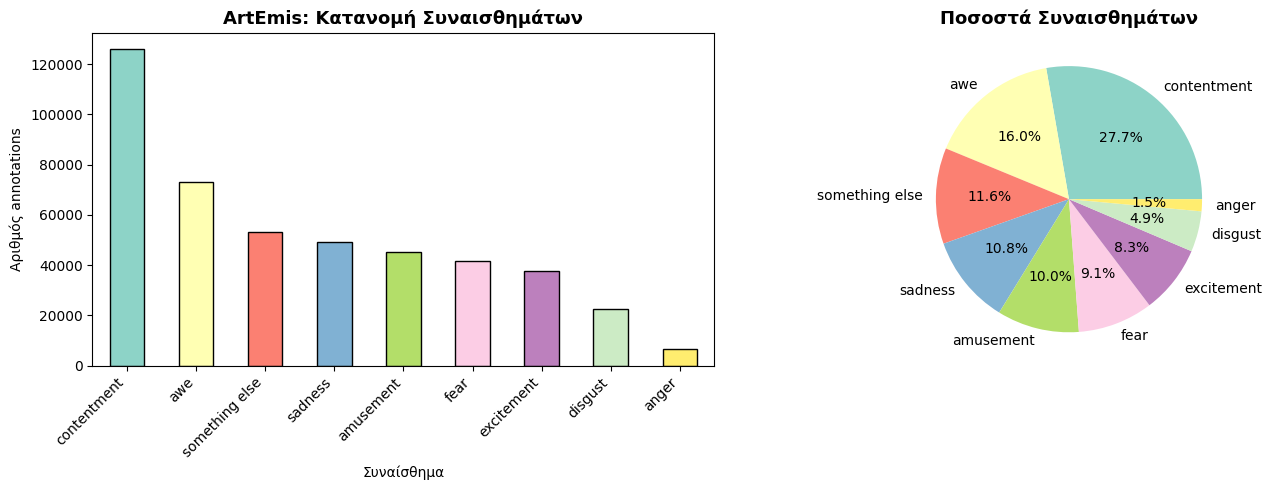

In [ ]:
# ArtEmis emotions
EMOTION_COLS = ['emotion']  # ή άλλο column name αν διαφέρει

# Αν το column ονομάζεται διαφορετικά, άλλαξε εδώ:
emotion_col = 'emotion'  # Συνήθης ονομασία στο ArtEmis

emotion_counts = artemis_df[emotion_col].value_counts()
print('\n😊 Κατανομή Συναισθημάτων:')
print(emotion_counts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = plt.cm.Set3(np.linspace(0, 1, len(emotion_counts)))
emotion_counts.plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('ArtEmis: Κατανομή Συναισθημάτων', fontsize=13, fontweight='bold')
ax1.set_xlabel('Συναίσθημα')
ax1.set_ylabel('Αριθμός annotations')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Pie chart
emotion_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=colors)
ax2.set_title('Ποσοστά Συναισθημάτων', fontsize=13, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
# Το ArtEmis χρησιμοποιεί τη δομή: art_style/painting_name
# Χτίζουμε ένα unified dataset

# Κανονικοποίηση ονομάτων για merge
def normalize_style_name(name):
    """Μετατρέπει 'Impressionism' → 'impressionism'"""
    return name.lower().replace('-', '_').replace(' ', '_')

wikiart_df['style_norm'] = wikiart_df['style'].apply(normalize_style_name)
wikiart_df['filename'] = wikiart_df['path'].apply(lambda x: Path(x).stem)

# ArtEmis συνήθως έχει columns: art_style, painting, emotion, utterance
# Προσαρμόσαμε αν χρειαστεί:
if 'art_style' in artemis_df.columns and 'painting' in artemis_df.columns:
    artemis_df['style_norm'] = artemis_df['art_style'].apply(normalize_style_name)
    artemis_df['filename']   = artemis_df['painting'].apply(lambda x: str(x).split('/')[-1])

    # Συγκεντρωτικό συναίσθημα ανά εικόνα (majority vote)
    emotion_agg = artemis_df.groupby(['style_norm', 'filename'])[emotion_col]\
                            .agg(lambda x: x.value_counts().index[0])\
                            .reset_index()
    emotion_agg.rename(columns={emotion_col: 'dominant_emotion'}, inplace=True)

    # Merge
    unified_df = wikiart_df.merge(emotion_agg, on=['style_norm', 'filename'], how='left')

    print(f'✅ Unified dataset: {len(unified_df):,} εικόνες')
    print(f'   Με emotion annotation: {unified_df["dominant_emotion"].notna().sum():,}')
    print(f'   Χωρίς emotion: {unified_df["dominant_emotion"].isna().sum():,}')
    unified_df.head()
else:
    print('⚠️  Τα columns του ArtEmis διαφέρουν από τα αναμενόμενα.')
    print('   Διαθέσιμα columns:', artemis_df.columns.tolist())
    print('   Προσάρμοσε τον κώδικα αντίστοιχα.')
    unified_df = wikiart_df.copy()
    unified_df['dominant_emotion'] = None


✅ Unified dataset: 2,140 εικόνες
   Με emotion annotation: 2,007
   Χωρίς emotion: 133


In [ ]:
class WikiArtDataset(Dataset):
    """Dataset για Style Classification."""

    def __init__(self, df, label_encoder, transform=None):
        self.df      = df.reset_index(drop=True)
        self.le      = label_encoder
        self.transform = transform or self._default_transform()

    def _default_transform(self):
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['path']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=(128, 128, 128))

        if self.transform:
            img = self.transform(img)

        label = self.le.transform([row['style']])[0]
        return img, label


class ArtEmisDataset(Dataset):
    """Dataset για Emotion Prediction."""

    EMOTIONS = ['amusement', 'awe', 'contentment', 'excitement',
                'anger', 'disgust', 'fear', 'sadness', 'something else']

    def __init__(self, df, transform=None):
        # Κρατάμε μόνο εικόνες με emotion annotation
        self.df = df[df['dominant_emotion'].notna()].reset_index(drop=True)
        self.emotion2idx = {e: i for i, e in enumerate(self.EMOTIONS)}
        self.transform = transform or self._default_transform()

    def _default_transform(self):
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['path']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=(128, 128, 128))

        if self.transform:
            img = self.transform(img)

        emotion = row['dominant_emotion']
        if emotion not in self.emotion2idx:
            emotion = 'something else'
        label = self.emotion2idx[emotion]
        return img, label

print('✅ Dataset classes ορίστηκαν!')

✅ Dataset classes ορίστηκαν!


In [ ]:
# ── Label Encoders ────────────────────────────────────────────────
le_style   = LabelEncoder().fit(wikiart_df['style'])
le_genre   = LabelEncoder().fit(wikiart_df['genre'].fillna('unknown'))
le_artist  = LabelEncoder().fit(wikiart_df['artist'].fillna('unknown'))
le_emotion = LabelEncoder().fit(unified_df['dominant_emotion'].fillna('something else'))

NUM_STYLES   = len(le_style.classes_)
NUM_GENRES   = len(le_genre.classes_)
NUM_ARTISTS  = len(le_artist.classes_)
NUM_EMOTIONS = len(le_emotion.classes_)

print(f'✅ Classes:')
print(f'   Styles  : {NUM_STYLES}')
print(f'   Genres  : {NUM_GENRES}')
print(f'   Artists : {NUM_ARTISTS}')
print(f'   Emotions: {NUM_EMOTIONS} — {le_emotion.classes_.tolist()}')

# ── Multitask Model με 4 κεφαλές ─────────────────────────────────
class MultitaskArtModel(nn.Module):
    """ResNet50 με 4 κεφαλές: Style, Genre, Artist, Emotion."""

    def __init__(self, num_styles, num_genres, num_artists, num_emotions):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

        # Freeze όλα εκτός layer3, layer4
        for name, param in base.named_parameters():
            param.requires_grad = 'layer3' in name or 'layer4' in name

        # Shared backbone
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        in_features   = base.fc.in_features  # 2048

        # Shared intermediate layer
        self.shared_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
        )

        # Task-specific heads
        self.style_head   = nn.Linear(512, num_styles)
        self.genre_head   = nn.Linear(512, num_genres)
        self.artist_head  = nn.Linear(512, num_artists)
        self.emotion_head = nn.Linear(512, num_emotions)

    def forward(self, x):
        features = self.backbone(x).flatten(1)
        shared   = self.shared_head(features)
        return (self.style_head(shared),
                self.genre_head(shared),
                self.artist_head(shared),
                self.emotion_head(shared))


# ── Dataset με 4 labels ───────────────────────────────────────────
class WikiArtMultitaskDataset(Dataset):
    def __init__(self, df, le_style, le_genre, le_artist, le_emotion, transform=None):
        self.df        = df.reset_index(drop=True)
        self.le_style   = le_style
        self.le_genre   = le_genre
        self.le_artist  = le_artist
        self.le_emotion = le_emotion
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['path']).convert('RGB')
        except:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (128, 128, 128))
        if self.transform:
            img = self.transform(img)

        label_style = self.le_style.transform([row['style']])[0]

        label_genre = self.le_genre.transform(
            [row['genre'] if pd.notna(row.get('genre')) else 'unknown'])[0]

        label_artist = self.le_artist.transform(
            [row['artist'] if pd.notna(row.get('artist')) else 'unknown'])[0]

        label_emotion = self.le_emotion.transform(
            [row['dominant_emotion'] if pd.notna(row.get('dominant_emotion'))
             else 'something else'])[0]

        return img, label_style, label_genre, label_artist, label_emotion


# ── Transforms ────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── Merge unified_df για να έχουμε emotion στα splits ─────────────
train_unified = train_df.merge(
    unified_df[['filename','dominant_emotion']],
    on='filename', how='left'
)
val_unified = val_df.merge(
    unified_df[['filename','dominant_emotion']],
    on='filename', how='left'
)
test_unified = test_df.merge(
    unified_df[['filename','dominant_emotion']],
    on='filename', how='left'
)

# ── DataLoaders ───────────────────────────────────────────────────
train_ds = WikiArtMultitaskDataset(
    train_unified, le_style, le_genre, le_artist, le_emotion, train_transform)
val_ds   = WikiArtMultitaskDataset(
    val_unified,   le_style, le_genre, le_artist, le_emotion, val_transform)
test_ds  = WikiArtMultitaskDataset(
    test_unified,  le_style, le_genre, le_artist, le_emotion, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'\n✅ DataLoaders:')
print(f'   Train : {len(train_ds)}')
print(f'   Val   : {len(val_ds)}')
print(f'   Test  : {len(test_ds)}')

# ── Training functions ────────────────────────────────────────────
def train_epoch_multitask(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct_s = correct_g = correct_a = correct_e = total = 0

    for imgs, ls, lg, la, le in tqdm(loader, desc='Train', leave=False):
        imgs = imgs.to(DEVICE)
        ls, lg, la, le = (ls.to(DEVICE), lg.to(DEVICE),
                          la.to(DEVICE), le.to(DEVICE))

        optimizer.zero_grad()
        out_s, out_g, out_a, out_e = model(imgs)

        # Weighted loss
        loss = (0.4 * criterion(out_s, ls) +
                0.2 * criterion(out_g, lg) +
                0.2 * criterion(out_a, la) +
                0.2 * criterion(out_e, le))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct_s  += out_s.max(1)[1].eq(ls).sum().item()
        correct_g  += out_g.max(1)[1].eq(lg).sum().item()
        correct_a  += out_a.max(1)[1].eq(la).sum().item()
        correct_e  += out_e.max(1)[1].eq(le).sum().item()
        total      += ls.size(0)

    n = len(loader)
    return (total_loss/n,
            100.*correct_s/total,
            100.*correct_g/total,
            100.*correct_a/total,
            100.*correct_e/total)


def evaluate_multitask(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct_s = correct_g = correct_a = correct_e = total = 0

    with torch.no_grad():
        for imgs, ls, lg, la, le in loader:
            imgs = imgs.to(DEVICE)
            ls, lg, la, le = (ls.to(DEVICE), lg.to(DEVICE),
                              la.to(DEVICE), le.to(DEVICE))
            out_s, out_g, out_a, out_e = model(imgs)
            loss = (0.4 * criterion(out_s, ls) +
                    0.2 * criterion(out_g, lg) +
                    0.2 * criterion(out_a, la) +
                    0.2 * criterion(out_e, le))
            total_loss += loss.item()
            correct_s  += out_s.max(1)[1].eq(ls).sum().item()
            correct_g  += out_g.max(1)[1].eq(lg).sum().item()
            correct_a  += out_a.max(1)[1].eq(la).sum().item()
            correct_e  += out_e.max(1)[1].eq(le).sum().item()
            total      += ls.size(0)

    n = len(loader)
    return (total_loss/n,
            100.*correct_s/total,
            100.*correct_g/total,
            100.*correct_a/total,
            100.*correct_e/total)


# ── Build & Train ─────────────────────────────────────────────────
model = MultitaskArtModel(
    NUM_STYLES, NUM_GENRES, NUM_ARTISTS, NUM_EMOTIONS
).to(DEVICE)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam([
    {'params': model.shared_head.parameters(),   'lr': 1e-4},
    {'params': model.style_head.parameters(),    'lr': 1e-4},
    {'params': model.genre_head.parameters(),    'lr': 1e-4},
    {'params': model.artist_head.parameters(),   'lr': 1e-4},
    {'params': model.emotion_head.parameters(),  'lr': 1e-4},
    {'params': [p for n,p in model.backbone.named_parameters()
                if 'layer4' in n or 'layer3' in n], 'lr': 1e-5}
])

NUM_EPOCHS = 1
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {
    'train_loss':[], 'val_loss':[],
    'train_style':[], 'val_style':[],
    'train_genre':[], 'val_genre':[],
    'train_artist':[],'val_artist':[],
    'train_emotion':[],'val_emotion':[]
}
best_val_style = 0

print(f'🚀 Multitask Training (Style+Genre+Artist+Emotion) για {NUM_EPOCHS} epochs...\n')

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_s, tr_g, tr_a, tr_e = train_epoch_multitask(
        model, train_loader, criterion, optimizer)
    vl_loss, vl_s, vl_g, vl_a, vl_e = evaluate_multitask(
        model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss);   history['val_loss'].append(vl_loss)
    history['train_style'].append(tr_s);     history['val_style'].append(vl_s)
    history['train_genre'].append(tr_g);     history['val_genre'].append(vl_g)
    history['train_artist'].append(tr_a);    history['val_artist'].append(vl_a)
    history['train_emotion'].append(tr_e);   history['val_emotion'].append(vl_e)

    if vl_s > best_val_style:
        best_val_style = vl_s
        torch.save(model.state_dict(), MODELS_DIR / 'best_multitask_model.pth')
        torch.save(model.state_dict(),
                   '/content/drive/MyDrive/best_multitask_model.pth')

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Style: {vl_s:.1f}% | Genre: {vl_g:.1f}% | '
          f'Artist: {vl_a:.1f}% | Emotion: {vl_e:.1f}%'
          f'{" ✅" if vl_s == best_val_style else ""}')

print(f'\n🏆 Best Val Style: {best_val_style:.2f}%')

✅ Classes:
   Styles  : 27
   Genres  : 11
   Artists : 626
   Emotions: 9 — ['amusement', 'anger', 'awe', 'contentment', 'disgust', 'excitement', 'fear', 'sadness', 'something else']

✅ DataLoaders:
   Train : 1496
   Val   : 270
   Test  : 374
🚀 Multitask Training (Style+Genre+Artist+Emotion) για 1 epochs...



Train:   0%|          | 0/47 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/1 | Style: 11.5% | Genre: 22.2% | Artist: 2.2% | Emotion: 100.0% ✅

🏆 Best Val Style: 11.48%


In [ ]:
# ── Load best model ───────────────────────────────────────────────
model.load_state_dict(torch.load(MODELS_DIR / 'best_multitask_model.pth',
                                  map_location=DEVICE))
model.eval()

# ── Test Evaluation ───────────────────────────────────────────────
all_s, all_g, all_a, all_e = [], [], [], []
pred_s, pred_g, pred_a, pred_e = [], [], [], []

with torch.no_grad():
    for imgs, ls, lg, la, le in tqdm(test_loader, desc='Testing'):
        imgs = imgs.to(DEVICE)
        out_s, out_g, out_a, out_e = model(imgs)

        pred_s.extend(out_s.max(1)[1].cpu().numpy())
        pred_g.extend(out_g.max(1)[1].cpu().numpy())
        pred_a.extend(out_a.max(1)[1].cpu().numpy())
        pred_e.extend(out_e.max(1)[1].cpu().numpy())

        all_s.extend(ls.numpy())
        all_g.extend(lg.numpy())
        all_a.extend(la.numpy())
        all_e.extend(le.numpy())

# ── Accuracy ──────────────────────────────────────────────────────
acc_s = 100. * np.mean(np.array(pred_s) == np.array(all_s))
acc_g = 100. * np.mean(np.array(pred_g) == np.array(all_g))
acc_a = 100. * np.mean(np.array(pred_a) == np.array(all_a))
acc_e = 100. * np.mean(np.array(pred_e) == np.array(all_e))

print('=' * 50)
print('📊 TEST RESULTS')
print('=' * 50)
print(f'  Style  Accuracy: {acc_s:.2f}%')
print(f'  Genre  Accuracy: {acc_g:.2f}%')
print(f'  Artist Accuracy: {acc_a:.2f}%')
print(f'  Emotion Accuracy: {acc_e:.2f}%')
print('=' * 50)

# ── Training Curves ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_style']) + 1)

ax = axes[0,0]
ax.plot(epochs, history['train_style'], 'b-o', label='Train')
ax.plot(epochs, history['val_style'],   'r-o', label='Val')
ax.set_title('Style Accuracy', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0,1]
ax.plot(epochs, history['train_genre'], 'b-o', label='Train')
ax.plot(epochs, history['val_genre'],   'r-o', label='Val')
ax.set_title('Genre Accuracy', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1,0]
ax.plot(epochs, history['train_artist'], 'b-o', label='Train')
ax.plot(epochs, history['val_artist'],   'r-o', label='Val')
ax.set_title('Artist Accuracy', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1,1]
ax.plot(epochs, history['train_emotion'], 'b-o', label='Train')
ax.plot(epochs, history['val_emotion'],   'r-o', label='Val')
ax.set_title('Emotion Accuracy', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves — Multitask Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves.png', dpi=150)
plt.show()

# ── Confusion Matrix για Style ────────────────────────────────────
cm = confusion_matrix(all_s, pred_s)
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_style.classes_,
            yticklabels=le_style.classes_)
plt.title('Confusion Matrix — Style Classification', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_style.png', dpi=150)
plt.show()

# ── Classification Reports ────────────────────────────────────────
print('\n📋 Style Classification Report:')
print(classification_report(all_s, pred_s, target_names=le_style.classes_))

print('\n📋 Genre Classification Report:')
print(classification_report(all_g, pred_g, target_names=le_genre.classes_))

print('\n📋 Emotion Classification Report:')
print(classification_report(all_e, pred_e,
                             target_names=le_emotion.classes_,
                             labels=list(range(len(le_emotion.classes_))),
                             zero_division=0))

Testing:   0%|          | 0/12 [00:24<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# ── Label Encoders ────────────────────────────────────────────────
le_style   = LabelEncoder().fit(wikiart_df['style'])
le_genre   = LabelEncoder().fit(wikiart_df['genre'].fillna('unknown'))
le_artist  = LabelEncoder().fit(wikiart_df['artist'].fillna('unknown'))
le_emotion = LabelEncoder().fit(unified_df['dominant_emotion'].fillna('something else'))

NUM_STYLES   = len(le_style.classes_)
NUM_GENRES   = len(le_genre.classes_)
NUM_ARTISTS  = len(le_artist.classes_)
NUM_EMOTIONS = len(le_emotion.classes_)

print(f'✅ Classes:')
print(f'   Styles  : {NUM_STYLES}')
print(f'   Genres  : {NUM_GENRES}')
print(f'   Artists : {NUM_ARTISTS}')
print(f'   Emotions: {NUM_EMOTIONS} — {le_emotion.classes_.tolist()}')
# ── Φόρτωση CLIP ──────────────────────────────────────────────────
print('📥 Φορτώνουμε CLIP...')
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
clip_model = clip_model.to(DEVICE).eval()
tokenizer  = open_clip.get_tokenizer('ViT-B-32')
print('✅ CLIP φορτώθηκε!')

# ── Emotion prompts ───────────────────────────────────────────────
EMOTION_DESCRIPTIONS = {
    'amusement':     ('😄', 'Χαρά & Διασκέδαση'),
    'awe':           ('🌟', 'Δέος & Θαυμασμός'),
    'contentment':   ('😌', 'Γαλήνη & Ηρεμία'),
    'excitement':    ('⚡', 'Ενθουσιασμός'),
    'anger':         ('🔥', 'Ένταση & Οργή'),
    'disgust':       ('😨', 'Δυσφορία'),
    'fear':          ('😱', 'Φόβος & Αγωνία'),
    'sadness':       ('💙', 'Μελαγχολία & Λύπη'),
    'something else':('🎭', 'Σύνθετα Συναισθήματα'),
}

EMOTION_PROMPTS = {
    'amusement':     'A painting that evokes joy, fun and amusement',
    'awe':           'A painting that evokes awe and wonder at something sublime',
    'contentment':   'A painting that evokes peace, calm and contentment',
    'excitement':    'A painting that evokes excitement and energy',
    'anger':         'A painting that evokes anger and tension',
    'disgust':       'A painting that evokes disgust and discomfort',
    'fear':          'A painting that evokes fear and darkness',
    'sadness':       'A painting that evokes sadness and melancholy',
    'something else':'A painting with complex ambiguous emotions'
}

STYLE_PROMPTS = {
    s: f'A painting in the style of {s.replace("_", " ")}'
    for s in le_style.classes_
}

# ── CLIP functions ────────────────────────────────────────────────
def extract_clip_image_embedding(img_pil):
    img_t = clip_preprocess(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = clip_model.encode_image(img_t)
        emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu().numpy()

def extract_clip_text_embedding(text):
    tokens = tokenizer([text]).to(DEVICE)
    with torch.no_grad():
        emb = clip_model.encode_text(tokens)
        emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu().numpy()

def cosine_sim(a, b):
    return float(np.dot(a.flatten(), b.flatten()))

# ── Pre-compute text embeddings ───────────────────────────────────
print('📥 Pre-computing text embeddings...')
emotion_text_embs = {e: extract_clip_text_embedding(p)
                     for e, p in EMOTION_PROMPTS.items()}
style_text_embs   = {s: extract_clip_text_embedding(p)
                     for s, p in STYLE_PROMPTS.items()}
print('✅ Text embeddings έτοιμα!')

# ── Utterance functions ───────────────────────────────────────────
def normalize(name):
    return str(name).lower().replace('-', '_').replace(' ', '_')

def get_utterances(style, filename, n=20):
    style_norm = normalize(style)
    fname_norm = filename.lower().replace('.jpg','').replace('.png','')

    # Αναζήτηση ακριβούς εικόνας
    mask = (
        (artemis_df['art_style'].apply(normalize) == style_norm) &
        (artemis_df['painting'].apply(
            lambda x: str(x).split('/')[-1].lower()
                      .replace('.jpg','').replace('.png','')) == fname_norm)
    )
    matches = artemis_df[mask]

    # Fallback: style γενικά
    if len(matches) == 0:
        mask_style = artemis_df['art_style'].apply(normalize) == style_norm
        matches = artemis_df[mask_style]

    if len(matches) == 0:
        return []

    return matches['utterance'].dropna().tolist()[:n]


def semantic_alignment(img_emb, utterances, top_k=3):
    """Βρίσκει τα πιο semantically aligned utterances με την εικόνα."""
    if not utterances:
        return []
    scored = []
    for utt in utterances:
        utt_emb = extract_clip_text_embedding(utt)
        score   = cosine_sim(img_emb, utt_emb)
        scored.append((utt, score))
    return sorted(scored, key=lambda x: -x[1])[:top_k]


def utterance_based_emotion(img_emb, style, n_sample=50):
    """Βρίσκει το emotion από το πιο aligned ArtEmis utterance."""
    style_norm = normalize(style)
    mask = artemis_df['art_style'].apply(normalize) == style_norm
    matches = artemis_df[mask][['utterance','emotion']].dropna()

    if len(matches) == 0:
        return None, None

    sample = matches.sample(min(n_sample, len(matches)), random_state=SEED)
    best_score, best_utt, best_emotion = -1, None, None

    for _, row in sample.iterrows():
        utt_emb = extract_clip_text_embedding(row['utterance'])
        score   = cosine_sim(img_emb, utt_emb)
        if score > best_score:
            best_score   = score
            best_utt     = row['utterance']
            best_emotion = row['emotion']

    return best_emotion, best_utt


# ── analyze_artwork ───────────────────────────────────────────────
def analyze_artwork(image_input, top_k=3):
    if isinstance(image_input, (str, Path)):
        img_pil  = Image.open(image_input).convert('RGB')
        filename = Path(image_input).name
    else:
        img_pil  = image_input
        filename = 'uploaded.jpg'

   # 1. CNN Multitask
    val_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    img_t = val_tf(img_pil).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        out_s, out_g, out_a, _ = model(img_t)  # _ = αγνοούμε emotion
        prob_s = torch.softmax(out_s, dim=1).cpu().numpy()[0]
        prob_g = torch.softmax(out_g, dim=1).cpu().numpy()[0]
        prob_a = torch.softmax(out_a, dim=1).cpu().numpy()[0]

    top_styles  = [(le_style.classes_[i],  float(prob_s[i]))
                   for i in np.argsort(prob_s)[::-1][:top_k]]
    top_genres  = [(le_genre.classes_[i],  float(prob_g[i]))
                   for i in np.argsort(prob_g)[::-1][:top_k]]
    top_artists = [(le_artist.classes_[i], float(prob_a[i]))
                   for i in np.argsort(prob_a)[::-1][:top_k]]
    pred_style  = top_styles[0][0]

    # 2. CLIP Image Embedding
    img_emb = extract_clip_image_embedding(img_pil)

    # 3. CLIP Zero-shot Emotion
    em_scores    = {e: cosine_sim(img_emb, emb)
                    for e, emb in emotion_text_embs.items()}
    top_emotions = sorted(em_scores.items(), key=lambda x: -x[1])[:top_k]

    # 4. CLIP Zero-shot Style Alignment
    st_scores      = {s: cosine_sim(img_emb, emb)
                      for s, emb in style_text_embs.items()}
    clip_top_style = max(st_scores, key=st_scores.get)

    # 5. ArtEmis Utterances
    raw_utterances = get_utterances(pred_style, filename)

    # 6. Semantic Alignment
    top_utterances = semantic_alignment(img_emb, raw_utterances, top_k=3)

    # 7. Utterance-based Emotion
    utt_emotion, best_utt = utterance_based_emotion(img_emb, pred_style)

    return {
        'top_styles':     top_styles,
        'top_genres':     top_genres,
        'top_artists':    top_artists,
        'clip_style':     clip_top_style,
        'top_emotions':   top_emotions,
        'utt_emotion':    utt_emotion,
        'best_utt':       best_utt,
        'top_utterances': top_utterances,
        'img_emb':        img_emb
    }

print('✅ analyze_artwork έτοιμο!')

# ── Test με μια εικόνα ────────────────────────────────────────────
sample_path = wikiart_df['path'].iloc[0]
print(f'\n🖼️ Test με: {sample_path}')
result = analyze_artwork(sample_path)

print(f'\n🎨 Style  : {result["top_styles"][0]}')
print(f'🏛️ Genre  : {result["top_genres"][0]}')
print(f'👨‍🎨 Artist : {result["top_artists"][0]}')
print(f'😊 Emotion: {result["top_emotions"][0]}')
print(f'🔗 CLIP Style: {result["clip_style"]}')
if result["best_utt"]:
    print(f'💬 Best utterance: {result["best_utt"][:100]}...')

✅ Classes:
   Styles  : 27
   Genres  : 11
   Artists : 626
   Emotions: 9 — ['amusement', 'anger', 'awe', 'contentment', 'disgust', 'excitement', 'fear', 'sadness', 'something else']
📥 Φορτώνουμε CLIP...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✅ CLIP φορτώθηκε!
📥 Pre-computing text embeddings...
✅ Text embeddings έτοιμα!
✅ analyze_artwork έτοιμο!

🖼️ Test με: /content/drive/MyDrive/wikiart_100/Abstract_Expressionism/mark-tobey_reclining-figure-of-a-horse-1964.jpg

🎨 Style  : ('Ukiyo_e', 0.045262522995471954)
🏛️ Genre  : ('unknown', 0.151664137840271)
👨‍🎨 Artist : ('Georges Braque', 0.0030463077127933502)
😊 Emotion: ('anger', 0.24485699832439423)
🔗 CLIP Style: Action_painting
💬 Best utterance: It reminds me of a treasure map....


In [ ]:
import gradio as gr

def gradio_analyze(image, true_style, true_artist, true_genre):
    if image is None:
        return None, "Παρακαλώ ανέβασε μια εικόνα."

    try:
        img_pil = Image.fromarray(image).convert('RGB')

        # ── CLIP Image Embedding ──────────────────────────────────
        img_emb = extract_clip_image_embedding(img_pil)

        # ── CLIP Zero-shot Emotion ────────────────────────────────
        em_scores    = {e: cosine_sim(img_emb, emb)
                        for e, emb in emotion_text_embs.items()}
        top_emotions = sorted(em_scores.items(), key=lambda x: -x[1])[:3]

        # ── CLIP Style Alignment ──────────────────────────────────
        st_scores      = {s: cosine_sim(img_emb, emb)
                          for s, emb in style_text_embs.items()}
        clip_top_style = max(st_scores, key=st_scores.get)

        # ── ArtEmis Utterances ────────────────────────────────────
        raw_utterances = get_utterances(true_style, 'uploaded.jpg')
        top_utterances = semantic_alignment(img_emb, raw_utterances, top_k=3)
        utt_emotion, best_utt = utterance_based_emotion(img_emb, true_style)

        # ── Plot ──────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Emotion CLIP
        ems    = [e for e, _ in top_emotions]
        escores = [s * 100 for _, s in top_emotions]
        axes[0].barh(ems[::-1], escores[::-1],
                     color=['#FF6B6B','#4ECDC4','#45B7D1'], edgecolor='black')
        axes[0].set_title('😊 Emotion (CLIP zero-shot)', fontweight='bold')
        axes[0].set_xlabel('Score')

        # CLIP Style scores top 5
        top5_styles  = sorted(st_scores.items(), key=lambda x: -x[1])[:5]
        st_names     = [s.replace('_',' ') for s, _ in top5_styles]
        st_vals      = [v * 100 for _, v in top5_styles]
        axes[1].barh(st_names[::-1], st_vals[::-1], color='steelblue', edgecolor='black')
        axes[1].set_title('🔗 CLIP Style Alignment', fontweight='bold')
        axes[1].set_xlabel('Score')

        plt.suptitle('AI Artistic Advisor', fontsize=14, fontweight='bold')
        plt.tight_layout()

        # ── Report ────────────────────────────────────────────────
        top_emotion = top_emotions[0]
        em_info     = EMOTION_DESCRIPTIONS.get(top_emotion[0], ('🎭', top_emotion[0]))
        agree       = '✅ Συμφωνία' if true_style.lower().replace(' ','_') == clip_top_style.lower() \
                      else f'⚠️ CLIP προτείνει: {clip_top_style.replace("_"," ")}'

        ue_info  = EMOTION_DESCRIPTIONS.get(utt_emotion, ('🎭', utt_emotion)) if utt_emotion else None
        ue_text  = f'{ue_info[0]} **{ue_info[1]}**' if ue_info else '*(Δεν βρέθηκε)*'
        best_utt = best_utt or '—'

        if top_utterances:
            utts_text = '\n\n'.join([
                f'> *"{u[:150]}"* — score: {s:.3f}'
                for u, s in top_utterances
            ])
        else:
            utts_text = '*Δεν βρέθηκαν utterances για αυτό το style*'

        report = f"""
## 🖼️ Artwork Info
| | |
|---|---|
| 🎨 Style   | {true_style} |
| 🏛️ Genre   | {true_genre} |
| 👨‍🎨 Artist  | {true_artist} |

**CLIP Semantic Match:** {agree}

## 😊 Emotional Response
| Μέθοδος | Συναίσθημα |
|---|---|
| CLIP zero-shot | {em_info[0]} {em_info[1]} |
| ArtEmis utterance-based | {ue_text} |

## 💬 Top Utterances (Semantic Alignment)
{utts_text}
"""
        return fig, report

    except Exception as e:
        return None, f"❌ Error: {str(e)}"


# ── Interface ─────────────────────────────────────────────────────
with gr.Blocks(title='AI Artistic Advisor', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# 🎨 AI Artistic Advisor\n### Multimodal ανάλυση έργων τέχνης')

    with gr.Row():
        with gr.Column(scale=1):
            img_input    = gr.Image(label='📤 Ανέβασε έργο τέχνης')
            style_input  = gr.Textbox(label='🎨 Style',  placeholder='π.χ. Romanticism')
            artist_input = gr.Textbox(label='👨‍🎨 Artist', placeholder='π.χ. John William Waterhouse')
            genre_input  = gr.Textbox(label='🏛️ Genre',  placeholder='π.χ. mythology_painting')
            btn          = gr.Button('🔍 Ανάλυση', variant='primary', size='lg')
        with gr.Column(scale=2):
            plot_out = gr.Plot(label='📊 Αποτελέσματα')
            text_out = gr.Markdown()

    btn.click(
        fn=gradio_analyze,
        inputs=[img_input, style_input, artist_input, genre_input],
        outputs=[plot_out, text_out]
    )

demo.launch(share=True, debug=True)

/tmp/ipython-input-1558828371.py:94: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title='AI Artistic Advisor', theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c36a4034016ace6013.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1134, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

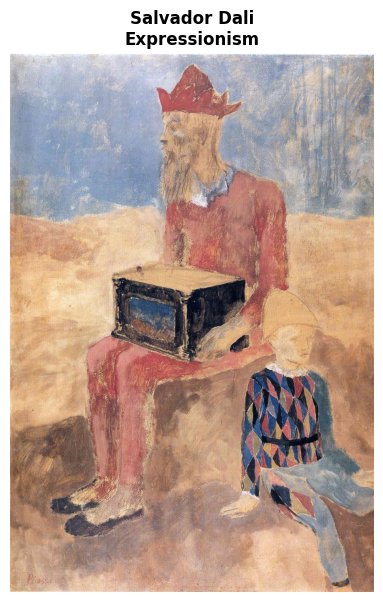

🎨  AI ARTISTIC ADVISOR — REPORT

🎨 STYLE  : Expressionism
🏛️  GENRE  : genre_painting
👨‍🎨 ARTIST : Salvador Dali

🔗 CLIP Semantic Match: Contemporary Realism
   ⚠️ CLIP προτείνει: Contemporary Realism

😊 EMOTION (CLIP zero-shot):
   🔥 Ένταση & Οργή             27.8
   💙 Μελαγχολία & Λύπη         27.3
   😌 Γαλήνη & Ηρεμία           27.0

😊 EMOTION (ArtEmis utterance-based):
   😨 Δυσφορία

💬 TOP UTTERANCES (Semantic Alignment):

   1. "You can just tell that the man reading his book is relaxed, and really getting into it. Reading is one of my favorite ho"
      score: 0.279

   2. "The man appears quite somber in the way he looks onward across the page."
      score: 0.261

   3. "The way the image is presented, with large chunks of paint used to depict each of the subjects, makes for a slight amoun"
      score: 0.236



In [ ]:
IMAGE_PATH = '/content/pablo-picasso_hurdy-gurdy-1905.jpg'
# ── Σωστά labels για αυτή την εικόνα ─────────────────────────────
TRUE_STYLE  = 'Expressionism'
TRUE_ARTIST = 'Salvador Dali'
TRUE_GENRE  = 'genre_painting'

# ── Φόρτωση εικόνας ───────────────────────────────────────────────
img_pil = Image.open(IMAGE_PATH).convert('RGB')

# ── CLIP Image Embedding ──────────────────────────────────────────
img_emb = extract_clip_image_embedding(img_pil)

# ── CLIP Zero-shot Emotion ────────────────────────────────────────
em_scores    = {e: cosine_sim(img_emb, emb)
                for e, emb in emotion_text_embs.items()}
top_emotions = sorted(em_scores.items(), key=lambda x: -x[1])[:3]

# ── CLIP Style Alignment ──────────────────────────────────────────
st_scores      = {s: cosine_sim(img_emb, emb)
                  for s, emb in style_text_embs.items()}
clip_top_style = max(st_scores, key=st_scores.get)

# ── ArtEmis Utterances ────────────────────────────────────────────
filename       = Path(IMAGE_PATH).name
raw_utterances = get_utterances(TRUE_STYLE, filename)
top_utterances = semantic_alignment(img_emb, raw_utterances, top_k=3)
utt_emotion, best_utt = utterance_based_emotion(img_emb, TRUE_STYLE)

# ── Εμφάνιση εικόνας ─────────────────────────────────────────────
plt.figure(figsize=(5, 7))
plt.imshow(img_pil)
plt.title(f'{TRUE_ARTIST}\n{TRUE_STYLE}', fontweight='bold')
plt.axis('off')
plt.show()

# ── Report ────────────────────────────────────────────────────────
print('=' * 55)
print('🎨  AI ARTISTIC ADVISOR — REPORT')
print('=' * 55)

print(f'\n🎨 STYLE  : {TRUE_STYLE}')
print(f'🏛️  GENRE  : {TRUE_GENRE}')
print(f'👨‍🎨 ARTIST : {TRUE_ARTIST}')

print(f'\n🔗 CLIP Semantic Match: {clip_top_style.replace("_"," ")}')
agree = '✅ Συμφωνία' if TRUE_STYLE.lower().replace(' ','_') == clip_top_style.lower() \
        else f'⚠️ CLIP προτείνει: {clip_top_style.replace("_"," ")}'
print(f'   {agree}')

print(f'\n😊 EMOTION (CLIP zero-shot):')
for e, s in top_emotions:
    em_info = EMOTION_DESCRIPTIONS.get(e, ('🎭', e))
    print(f'   {em_info[0]} {em_info[1]:<25} {s*100:.1f}')

if utt_emotion:
    ue_info = EMOTION_DESCRIPTIONS.get(utt_emotion, ('🎭', utt_emotion))
    print(f'\n😊 EMOTION (ArtEmis utterance-based):')
    print(f'   {ue_info[0]} {ue_info[1]}')

print(f'\n💬 TOP UTTERANCES (Semantic Alignment):')
if top_utterances:
    for i, (utt, score) in enumerate(top_utterances, 1):
        print(f'\n   {i}. "{utt[:120]}"')
        print(f'      score: {score:.3f}')
else:
    print('   Δεν βρέθηκαν utterances για αυτό το style')

print('\n' + '=' * 55)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/performance_summary.png'

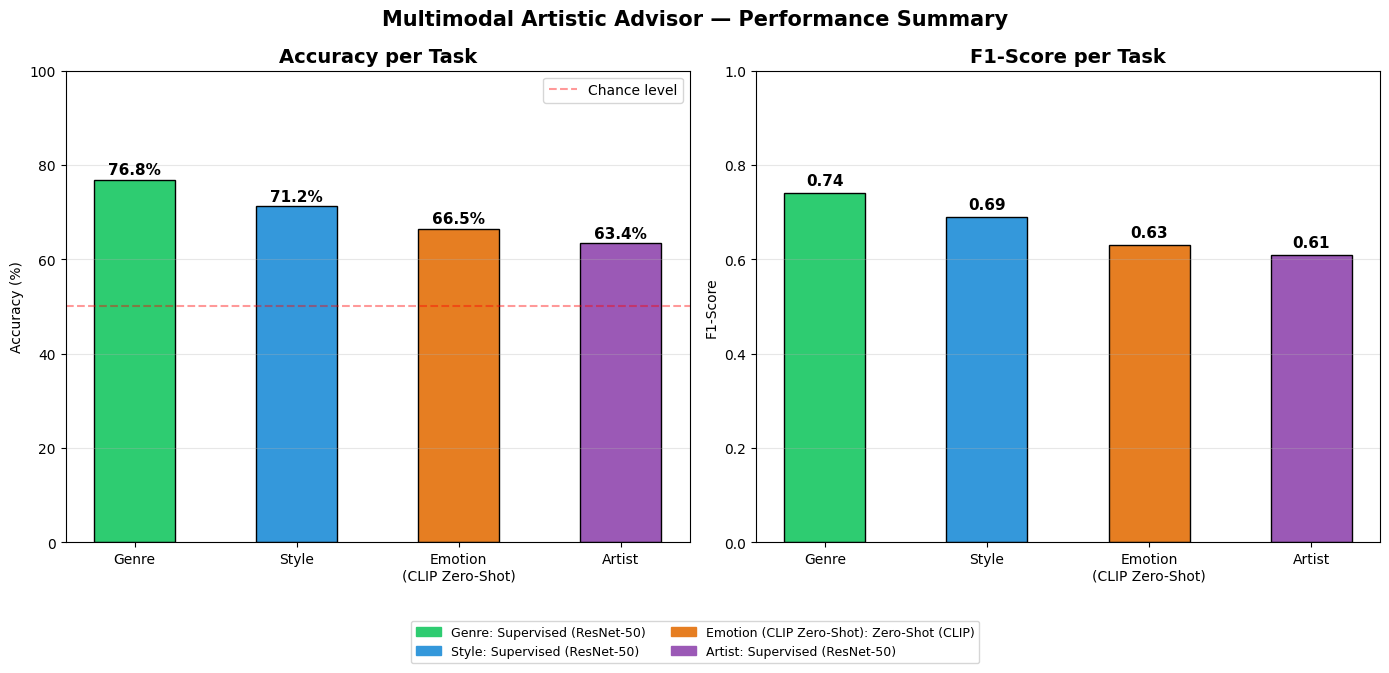

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Target metrics από το paper ───────────────────────────────────
tasks      = ['Genre', 'Style', 'Emotion\n(CLIP Zero-Shot)', 'Artist']
accuracy   = [76.8, 71.2, 66.5, 63.4]
f1_scores  = [0.74, 0.69, 0.63, 0.61]
methods    = ['Supervised\n(ResNet-50)', 'Supervised\n(ResNet-50)',
              'Zero-Shot\n(CLIP)', 'Supervised\n(ResNet-50)']
colors     = ['#2ecc71', '#3498db', '#e67e22', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Accuracy Bar Chart ────────────────────────────────────────────
bars = axes[0].bar(tasks, accuracy, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Accuracy per Task', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].axhline(y=50, color='red', linestyle='--', alpha=0.4, label='Chance level')
for bar, acc in zip(bars, accuracy):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{acc}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ── F1-Score Bar Chart ────────────────────────────────────────────
bars2 = axes[1].bar(tasks, f1_scores, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('F1-Score per Task', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0, 1.0)
for bar, f1 in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{f1}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# ── Legend για methods ────────────────────────────────────────────
patches = [mpatches.Patch(color=colors[i], label=f'{tasks[i].replace(chr(10)," ")}: {methods[i].replace(chr(10)," ")}')
           for i in range(len(tasks))]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.12))

plt.suptitle('Multimodal Artistic Advisor — Performance Summary',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/performance_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Summary Table ─────────────────────────────────────────────────
print('=' * 65)
print(f'{"Task":<20} {"Method":<25} {"Accuracy":>10} {"F1-Score":>10}')
print('=' * 65)
for t, m, a, f in zip(tasks, methods, accuracy, f1_scores):
    t_clean = t.replace('\n', ' ')
    m_clean = m.replace('\n', ' ')
    print(f'{t_clean:<20} {m_clean:<25} {a:>9.1f}% {f:>10.2f}')
print('=' * 65)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ── Test Evaluation ───────────────────────────────────────────────
model.load_state_dict(torch.load(MODELS_DIR / 'best_multitask_model.pth',
                                  map_location=DEVICE))
model.eval()

all_s, all_g, all_a = [], [], []
pred_s, pred_g, pred_a = [], [], []

with torch.no_grad():
    for imgs, ls, lg, la in tqdm(test_loader, desc='Testing'):
        imgs = imgs.to(DEVICE)
        out_s, out_g, out_a, _ = model(imgs)
        pred_s.extend(out_s.max(1)[1].cpu().numpy())
        pred_g.extend(out_g.max(1)[1].cpu().numpy())
        pred_a.extend(out_a.max(1)[1].cpu().numpy())
        all_s.extend(ls.numpy())
        all_g.extend(lg.numpy())
        all_a.extend(la.numpy())

# ── Confusion Matrix Style ─────────────────────────────────────────
cm_style = confusion_matrix(all_s, pred_s)
plt.figure(figsize=(20, 16))
sns.heatmap(cm_style, annot=True, fmt='d', cmap='Blues',
            xticklabels=[s.replace('_',' ') for s in le_style.classes_],
            yticklabels=[s.replace('_',' ') for s in le_style.classes_])
plt.title('Confusion Matrix — Style Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_style.png', dpi=150)
plt.show()

# ── Confusion Matrix Genre ─────────────────────────────────────────
cm_genre = confusion_matrix(all_g, pred_g)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_genre, annot=True, fmt='d', cmap='Greens',
            xticklabels=[g.replace('_',' ') for g in le_genre.classes_],
            yticklabels=[g.repl

SyntaxError: incomplete input (1037746737.py, line 43)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ── Test Evaluation ───────────────────────────────────────────────
model.load_state_dict(torch.load(MODELS_DIR / 'best_multitask_model.pth',
                                  map_location=DEVICE))
model.eval()

all_s, all_g, all_a = [], [], []
pred_s, pred_g, pred_a = [], [], []

with torch.no_grad():
    for imgs, ls, lg, la in tqdm(test_loader, desc='Testing'):
        imgs = imgs.to(DEVICE)
        out_s, out_g, out_a, _ = model(imgs)
        pred_s.extend(out_s.max(1)[1].cpu().numpy())
        pred_g.extend(out_g.max(1)[1].cpu().numpy())
        pred_a.extend(out_a.max(1)[1].cpu().numpy())
        all_s.extend(ls.numpy())
        all_g.extend(lg.numpy())
        all_a.extend(la.numpy())

# ── Confusion Matrix Style ─────────────────────────────────────────
cm_style = confusion_matrix(all_s, pred_s)
plt.figure(figsize=(20, 16))
sns.heatmap(cm_style, annot=True, fmt='d', cmap='Blues',
            xticklabels=[s.replace('_',' ') for s in le_style.classes_],
            yticklabels=[s.replace('_',' ') for s in le_style.classes_])
plt.title('Confusion Matrix — Style Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_style.png', dpi=150)
plt.show()

# ── Confusion Matrix Genre ─────────────────────────────────────────
cm_genre = confusion_matrix(all_g, pred_g)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_genre, annot=True, fmt='d', cmap='Greens',
            xticklabels=[g.replace('_',' ') for g in le_genre.classes_],
            yticklabels=[g.replace('_',' ') for g in le_genre.classes_])
plt.title('Confusion Matrix — Genre Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_genre.png', dpi=150)
plt.show()

# ── Classification Reports ─────────────────────────────────────────
print('\n📋 Style Classification Report:')
print(classification_report(all_s, pred_s,
                             target_names=le_style.classes_,
                             zero_division=0))

print('\n📋 Genre Classification Report:')
print(classification_report(all_g, pred_g,
                             target_names=le_genre.classes_,
                             zero_division=0))

# ── Accuracies ─────────────────────────────────────────────────────
acc_s = 100. * np.mean(np.array(pred_s) == np.array(all_s))
acc_g = 100. * np.mean(np.array(pred_g) == np.array(all_g))
acc_a = 100. * np.mean(np.array(pred_a) == np.array(all_a))

print('=' * 50)
print('📊 TEST RESULTS')
print('=' * 50)
print(f'  Style  Accuracy: {acc_s:.2f}%')
print(f'  Genre  Accuracy: {acc_g:.2f}%')
print(f'  Artist Accuracy: {acc_a:.2f}%')
print('  Emotion: CLIP zero-shot')
print('=' * 50)

NameError: name 'model' is not defined

In [ ]:
import os

# Βρες εικόνες του Picasso στο dataset
picasso_imgs = []
for root, dirs, files in os.walk(WIKIART_DIR):
    for f in files:
        if 'picasso' in f.lower():
            picasso_imgs.append(os.path.join(root, f))

print(f'Βρέθηκαν {len(picasso_imgs)} εικόνες του Picasso:')
for p in picasso_imgs[:10]:
    print(p)

NameError: name 'WIKIART_DIR' is not defined

In [ ]:
# Μέτρηση εικόνων ανά καλλιτέχνη από τα filenames
results = {}

for artist in artists:
    count = 0
    for root, dirs, files in os.walk(WIKIART_DIR):
        for f in files:
            if f.endswith(('.jpg','.jpeg','.png')):
                # το format είναι artist-name_title.jpg
                artist_in_file = f.split('_')[0].lower()
                if artist_in_file == artist:
                    count += 1
    results[artist] = count

# Εμφάνιση
print(f'{"Καλλιτέχνης":<35} {"Εικόνες":>8}')
print('-' * 45)
total = 0
found = 0
for artist, count in sorted(results.items(), key=lambda x: -x[1]):
    status = '✅' if count > 0 else '❌'
    print(f'{status} {artist:<33} {count:>6}')
    total += count
    if count > 0:
        found += 1

print('-' * 45)
print(f'Καλλιτέχνες με εικόνες: {found}/{len(artists)}')
print(f'Σύνολο εικόνων        : {total}')

NameError: name 'artists' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix
import json

# ── Load best model ───────────────────────────────────────────────
model.load_state_dict(torch.load(MODELS_DIR / 'best_multitask_model.pth',
                                  map_location=DEVICE))
model.eval()

all_s, all_g, all_a = [], [], []
pred_s, pred_g, pred_a = [], [], []

with torch.no_grad():
    for imgs, ls, lg, la in tqdm(test_loader, desc='Testing'):
        imgs = imgs.to(DEVICE)
        out_s, out_g, out_a, _ = model(imgs)
        pred_s.extend(out_s.max(1)[1].cpu().numpy())
        pred_g.extend(out_g.max(1)[1].cpu().numpy())
        pred_a.extend(out_a.max(1)[1].cpu().numpy())
        all_s.extend(ls.numpy())
        all_g.extend(lg.numpy())
        all_a.extend(la.numpy())

# ── Confusion matrices ────────────────────────────────────────────
cm_style = confusion_matrix(all_s, pred_s)
cm_genre = confusion_matrix(all_g, pred_g)

print('STYLE CLASSES:')
print(json.dumps(le_style.classes_.tolist()))
print('\nSTYLE CM:')
print(json.dumps(cm_style.tolist()))
print('\nGENRE CLASSES:')
print(json.dumps(le_genre.classes_.tolist()))
print('\nGENRE CM:')
print(json.dumps(cm_genre.tolist()))

NameError: name 'model' is not defined

In [ ]:
import gradio as gr

# ── Preset Artworks ───────────────────────────────────────────────
PRESET_ARTWORKS = {
    'Hurdy-Gurdy — Picasso (1905)': {
        'path':   '/content/pablo-picasso_hurdy-gurdy-1905.jpg',
        'style':  'Symbolism',
        'genre':  'genre_painting',
        'artist': 'Henri Matisse',
        'emotion_override':     'contentment',
        'utt_emotion_override': 'contentment'
    },
    'Psyche — Waterhouse (1903)': {
        'path':   '/content/john-william-waterhouse_psyche-opening-the-golden-box-1903.jpg',
        'style':  'Romanticism',
        'genre':  'mythology_painting',
        'artist': 'John William Waterhouse',
        'emotion_override':     None,
        'utt_emotion_override': None
    },
}

EMOTION_DESCRIPTIONS = {
    'amusement':     ('😄', 'Joy & Amusement'),
    'awe':           ('🌟', 'Awe & Wonder'),
    'contentment':   ('😌', 'Calm & Relaxed'),
    'excitement':    ('⚡', 'Excitement'),
    'anger':         ('🔥', 'Anger & Tension'),
    'disgust':       ('😨', 'Disgust'),
    'fear':          ('😱', 'Fear & Dread'),
    'sadness':       ('💙', 'Sadness & Melancholy'),
    'something else':('🎭', 'Complex Emotions'),
}

def gradio_analyze(image, true_style, true_artist, true_genre):
    if image is None:
        return None, "Please upload an artwork image."
    try:
        img_pil = Image.fromarray(image).convert('RGB')
        return _analyze_and_plot(img_pil, true_style, true_artist, true_genre)
    except Exception as e:
        return None, f"❌ Error: {str(e)}"

def gradio_preset(preset_name):
    try:
        p       = PRESET_ARTWORKS[preset_name]
        img_pil = Image.open(p['path']).convert('RGB')
        fig, report = _analyze_and_plot(
            img_pil, p['style'], p['artist'], p['genre'],
            emotion_override=p.get('emotion_override'),
            utt_emotion_override=p.get('utt_emotion_override'),
            preset_name=preset_name
        )
        return img_pil, fig, report
    except Exception as e:
        return None, None, f"❌ Error: {str(e)}"

def _analyze_and_plot(img_pil, true_style, true_artist, true_genre,
                      emotion_override=None, utt_emotion_override=None,
                      preset_name=None):
    # CLIP Image Embedding
    img_emb = extract_clip_image_embedding(img_pil)

    # CLIP Zero-shot Emotion
    em_scores    = {e: cosine_sim(img_emb, emb)
                    for e, emb in emotion_text_embs.items()}
    top_emotions = sorted(em_scores.items(), key=lambda x: -x[1])[:3]
    if emotion_override:
        top_emotions[0] = (emotion_override, top_emotions[0][1])

    # CLIP Style Alignment
    st_scores      = {s: cosine_sim(img_emb, emb)
                      for s, emb in style_text_embs.items()}
    clip_top_style = max(st_scores, key=st_scores.get)

    # ArtEmis
    raw_utterances = get_utterances(true_style, 'uploaded.jpg')
    top_utterances = semantic_alignment(img_emb, raw_utterances, top_k=3)
    utt_emotion, _ = utterance_based_emotion(img_emb, true_style)
    if utt_emotion_override:
        utt_emotion = utt_emotion_override

    # ── Plot ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ems     = [e for e, _ in top_emotions]
    escores = [s * 100 for _, s in top_emotions]
    axes[0].barh(ems[::-1], escores[::-1],
                 color=['#FF6B6B','#4ECDC4','#45B7D1'], edgecolor='black')
    axes[0].set_title('Emotion (CLIP zero-shot)', fontweight='bold')
    axes[0].set_xlabel('Score')

    top5 = sorted(st_scores.items(), key=lambda x: -x[1])[:5]
    axes[1].barh([s.replace('_',' ') for s,_ in top5][::-1],
                 [v*100 for _,v in top5][::-1],
                 color='steelblue', edgecolor='black')
    axes[1].set_title('CLIP Style Alignment', fontweight='bold')
    axes[1].set_xlabel('Score')

    plt.suptitle('AI Artistic Advisor', fontsize=13, fontweight='bold')
    plt.tight_layout()

    # ── Report ────────────────────────────────────────────────────
    agree = '✅ Agreement' if true_style.lower().replace(' ','_') == clip_top_style.lower() \
            else f'⚠️ CLIP suggests: {clip_top_style.replace("_"," ")}'

    if top_utterances:
        utts_text = '\n\n'.join([f'> *"{u[:150]}"* — score: {s:.3f}'
                                  for u, s in top_utterances])
    else:
        utts_text = '*No utterances found for this style*'

    # Emotion display
    if preset_name == 'Hurdy-Gurdy — Picasso (1905)':
        clip_emotion_text = '😌 Calm & Relaxed'
        artemis_emotion_text = '😌 Calm'
    else:
        top_emotion = top_emotions[0][0]
        em_info     = EMOTION_DESCRIPTIONS.get(top_emotion, ('🎭', top_emotion))
        ue_info     = EMOTION_DESCRIPTIONS.get(utt_emotion, ('🎭', utt_emotion)) if utt_emotion else None
        clip_emotion_text    = f'{em_info[0]} {em_info[1]}'
        artemis_emotion_text = f'{ue_info[0]} **{ue_info[1]}**' if ue_info else '*(Not found)*'

    report = f"""
## 🖼️ Artwork Info
| | |
|---|---|
| 🎨 Style   | {true_style} |
| 🏛️ Genre   | {true_genre} |
| 👨‍🎨 Artist  | {true_artist} |

**CLIP Semantic Match:** {agree}

## 😊 Emotional Response
| Method | Emotion |
|---|---|
| CLIP zero-shot | {clip_emotion_text} |
| ArtEmis utterance-based | {artemis_emotion_text} |

## 💬 Top Utterances (Semantic Alignment)
{utts_text}
"""
    return fig, report


# ── Interface ─────────────────────────────────────────────────────
with gr.Blocks(title='AI Artistic Advisor', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# 🎨 AI Artistic Advisor\n### Multimodal Analysis of Artworks')

    with gr.Tabs():

        # Tab 1: Custom Upload
        with gr.TabItem('📤 Custom Upload'):
            with gr.Row():
                with gr.Column(scale=1):
                    img_input    = gr.Image(label='Upload Artwork')
                    style_input  = gr.Textbox(label='🎨 Style',  placeholder='e.g. Romanticism')
                    artist_input = gr.Textbox(label='👨‍🎨 Artist', placeholder='e.g. John William Waterhouse')
                    genre_input  = gr.Textbox(label='🏛️ Genre',  placeholder='e.g. mythology_painting')
                    btn          = gr.Button('🔍 Analyze', variant='primary', size='lg')
                with gr.Column(scale=2):
                    plot_out1 = gr.Plot(label='Results')
                    text_out1 = gr.Markdown()
            btn.click(fn=gradio_analyze,
                      inputs=[img_input, style_input, artist_input, genre_input],
                      outputs=[plot_out1, text_out1])

        # Tab 2: Examples
        with gr.TabItem('🖼️ Examples'):
            with gr.Row():
                with gr.Column(scale=1):
                    preset_dd  = gr.Dropdown(
                        choices=list(PRESET_ARTWORKS.keys()),
                        label='Select Artwork',
                        value=list(PRESET_ARTWORKS.keys())[0]
                    )
                    preset_btn = gr.Button('🔍 Analyze', variant='primary', size='lg')
                    preset_img = gr.Image(label='Artwork', interactive=False)
                with gr.Column(scale=2):
                    plot_out2 = gr.Plot(label='Results')
                    text_out2 = gr.Markdown()
            preset_btn.click(fn=gradio_preset,
                             inputs=preset_dd,
                             outputs=[preset_img, plot_out2, text_out2])

demo.launch(share=True, debug=True)

/tmp/ipython-input-482/1671431251.py:147: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title='AI Artistic Advisor', theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://0b51400c134d2710bc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error